<img src="Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Santiago Boente

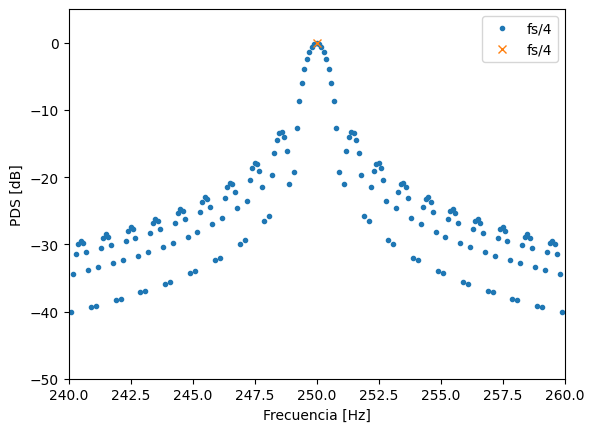

1.0000000000000002


In [12]:
import numpy as np
import matplotlib.pyplot as plt

"vmax: Amplitud maxima , dc: valor medio , ff: frecuencia, ph: fase en radianes , nn: numero de muestras , fs: frecuencia de muestreo" 

A = np.sqrt(2)
N = 1000
k0 = N/4
fs = 1000
f0 = k0 * fs/N

def mi_funcion_sen(vmax, dc , ff , ph , nn , fs):
    
    ts = 1/fs
    tt = np.arange(0, nn, 1)*ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx 
"tt: vector de tiempo , xx: vector de señal"
    
tt, xx = mi_funcion_sen(A , 0 , f0 , 0 , N , fs)


X1 = np.fft.fft(xx)/N
P1 = 2*np.abs(X1)**2
P1_dB = 10*np.log10(P1[:N//2] + 1e-12)

freq1 = np.arange(0 , fs/2, fs/N)

zz = np.zeros_like(xx)
zzzz = np.tile(zz, 9)
xxzz = np.concatenate((xx, zzzz), axis = None)

M = len(xxzz)
XX = np.fft.fft(xxzz)/N
XX_mod = 2 * (np.abs(XX[:M//2])**2)

#paso a dB
M = len(xxzz)
XX_f0 = 10 * np.log10(XX_mod)

freq = np.arange(0, fs/2, fs/(M))


plt.figure()
plt.xlim(240, 260)
plt.ylim(-50, 5)
plt.plot(freq, XX_f0, marker = 'o', label = 'fs/4', linestyle = '', markersize=3)
plt.plot(freq1, P1_dB, marker = 'x', label = 'fs/4', linestyle = '')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PDS [dB]")
plt.legend()
plt.show()

print(np.mean(xx**2))

0.9989999999999996


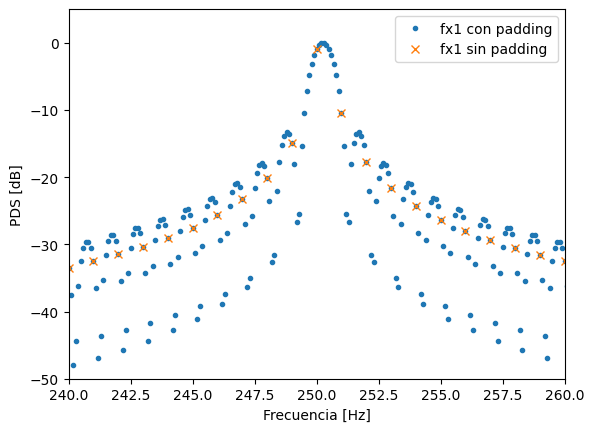

In [10]:

k0 = N/4 + 0.25
fx1 = k0 * fs/N

tt, xx = mi_funcion_sen(A , 0 , fx1 , 0 , N , fs)

#sin padding
X1 = np.fft.fft(xx)/N
P1 = 2*np.abs(X1)**2
P1_dB = 10*np.log10(P1[:N//2] + 1e-12)

freq1 = np.arange(0 , fs/2, fs/N)

#con padding
zz = np.zeros_like(xx)
zzzz = np.tile(zz, 9)
xxzz = np.concatenate((xx, zzzz), axis = None)

M = len(xxzz)
XX = np.fft.fft(xxzz)/N
XX_mod = 2 * (np.abs(XX[:M//2])**2)

#paso a dBM = len(xxzz)
XX_fx1 = 10 * np.log10(XX_mod)


freq = np.arange(0, fs/2, fs/(M))

plt.figure()
plt.xlim(240, 260)
plt.ylim(-50, 5)
plt.plot(freq, XX_fx1, marker = 'o', label = 'fx1 con padding', linestyle = '', markersize=3)
plt.plot(freq1, P1_dB, marker = 'x', label = 'fx1 sin padding', linestyle = '')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PDS [dB]")
plt.legend()

print(np.mean(xx**2))

1.0000000000000004


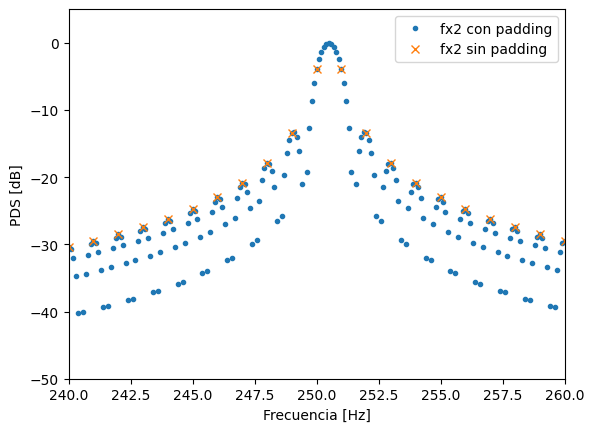

In [11]:
k0 = N/4 + 0.5
fx2 = k0 * fs/N

tt, xx = mi_funcion_sen(A , 0 , fx2 , 0 , N , fs)

#sin padding
X1 = np.fft.fft(xx)/N
P1 = 2*np.abs(X1)**2
P1_dB = 10*np.log10(P1[:N//2] + 1e-12)

freq1 = np.arange(0 , fs/2, fs/N)

zz = np.zeros_like(xx)
zzzz = np.tile(zz, 9)
xxzz = np.concatenate((xx, zzzz), axis = None)

#con padding
M = len(xxzz)
XX = np.fft.fft(xxzz)/N
XX_mod = 2 * (np.abs(XX[:M//2])**2)

#paso a dBM = len(xxzz)
XX_fx2 = 10 * np.log10(XX_mod)


freq = np.arange(0, fs/2, fs/(M))

plt.figure()
plt.xlim(240, 260)
plt.ylim(-50, 5)
plt.plot(freq, XX_fx2, marker = 'o', label = 'fx2 con padding', linestyle = '', markersize=3)
plt.plot(freq1, P1_dB, marker = 'x', label = 'fx2 sin padding', linestyle = '')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PDS [dB]")
plt.legend()

print(np.mean(xx**2))